In [1]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.models import load_model

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             r2_score)

import os, json, zipfile, pickle, glob
from datetime import datetime

In [2]:
path = kagglehub.dataset_download(
    "robikscube/hourly-energy-consumption"
)

print("✅ Download Complete!")
print(f"📁 Path : {path}")

csv_files = glob.glob(os.path.join(path, '**/*.csv'),
                      recursive=True)
print(f"\n📄 CSV Files Found: {len(csv_files)}")
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"   {os.path.basename(f):<40} ({size_mb:.1f} MB)")

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
✅ Download Complete!
📁 Path : /kaggle/input/hourly-energy-consumption

📄 CSV Files Found: 13
   DOM_hourly.csv                           (3.1 MB)
   EKPC_hourly.csv                          (1.2 MB)
   DUQ_hourly.csv                           (3.1 MB)
   DAYTON_hourly.csv                        (3.1 MB)
   PJME_hourly.csv                          (3.9 MB)
   PJM_Load_hourly.csv                      (0.9 MB)
   NI_hourly.csv                            (1.5 MB)
   FE_hourly.csv                            (1.6 MB)
   COMED_hourly.csv                         (1.8 MB)
   AEP_hourly.csv                           (3.2 MB)
   pjm_hourly_est.csv                       (12.1 MB)
   DEOK_hourly.csv                          (1.5 MB)
   PJMW_hourly.csv                          (3.7 MB)


In [3]:
target_file = None
for f in csv_files:
    if 'AEP_hourly' in f:
        target_file = f
        break

if target_file is None:
    target_file = max(csv_files, key=os.path.getsize)

print(f"📄 Loading : {os.path.basename(target_file)}")
df_raw = pd.read_csv(target_file)

print(f"\n✅ Dataset Loaded!")
print(f"   Shape   : {df_raw.shape}")
print(f"   Columns : {list(df_raw.columns)}")
print(f"\n🔍 First 5 Rows:")
display(df_raw.head())

print(f"\n📊 Basic Stats:")
display(df_raw.describe())

📄 Loading : AEP_hourly.csv

✅ Dataset Loaded!
   Shape   : (121273, 2)
   Columns : ['Datetime', 'AEP_MW']

🔍 First 5 Rows:


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0



📊 Basic Stats:


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [4]:
df = df_raw.copy()

# --- 4.1 Rename Columns ---
print("\n📌 Step 1: Column Rename...")
df.columns = ['Datetime', 'Energy_MW']
print(f"   Columns : {list(df.columns)}")


📌 Step 1: Column Rename...
   Columns : ['Datetime', 'Energy_MW']


In [5]:
# --- 4.2 Parse Datetime ---
print("\n📌 Step 2: Datetime Parsing...")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"   Range : {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"   Hours : {len(df):,}")


📌 Step 2: Datetime Parsing...
   Range : 2004-10-01 01:00:00 → 2018-08-03 00:00:00
   Hours : 121,273


In [6]:
# --- 4.3 Missing Values ---
print("\n📌 Step 3: Missing Values...")
missing = df.isnull().sum()
print(f"   Datetime  Null : {missing['Datetime']}")
print(f"   Energy_MW Null : {missing['Energy_MW']}")
if missing['Energy_MW'] > 0:
    df['Energy_MW'] = df['Energy_MW'].interpolate('linear')
    print(f"   ✅ Interpolated {missing['Energy_MW']} values")
else:
    print("   ✅ No Missing Values!")


📌 Step 3: Missing Values...
   Datetime  Null : 0
   Energy_MW Null : 0
   ✅ No Missing Values!


In [7]:
# --- 4.4 Duplicates ---
print("\n📌 Step 4: Duplicate Check...")
dups = df.duplicated(subset=['Datetime']).sum()
print(f"   Duplicates : {dups}")
if dups > 0:
    df.drop_duplicates(subset=['Datetime'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   ✅ Removed {dups} duplicates")


📌 Step 4: Duplicate Check...
   Duplicates : 4
   ✅ Removed 4 duplicates


In [8]:
# --- 4.5 Invalid Values ---
print("\n📌 Step 5: Invalid Values...")
neg = (df['Energy_MW'] <= 0).sum()
print(f"   Negative/Zero : {neg}")
if neg > 0:
    med = df['Energy_MW'].median()
    df.loc[df['Energy_MW'] <= 0, 'Energy_MW'] = med
    print(f"   ✅ Replaced with median ({med:.2f})")


📌 Step 5: Invalid Values...
   Negative/Zero : 0


In [9]:
# --- 4.6 Outlier Clipping (IQR) ---
print("\n📌 Step 6: Outlier Detection...")
Q1  = df['Energy_MW'].quantile(0.25)
Q3  = df['Energy_MW'].quantile(0.75)
IQR = Q3 - Q1
lo  = Q1 - 3.0 * IQR
hi  = Q3 + 3.0 * IQR
out = ((df['Energy_MW'] < lo) | (df['Energy_MW'] > hi)).sum()
print(f"   Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR:.1f}")
print(f"   Bounds   : [{lo:.1f}, {hi:.1f}]")
print(f"   Outliers : {out}")
df['Energy_MW'] = df['Energy_MW'].clip(lower=lo, upper=hi)
print(f"   ✅ Clipped to bounds")

print(f"\n📊 After Cleaning:")
print(f"   Min    : {df['Energy_MW'].min():.2f} MW")
print(f"   Max    : {df['Energy_MW'].max():.2f} MW")
print(f"   Mean   : {df['Energy_MW'].mean():.2f} MW")
print(f"   Std    : {df['Energy_MW'].std():.2f} MW")
print(f"\n✅ Cleaning Done! Shape: {df.shape}")


📌 Step 6: Outlier Detection...
   Q1=13630.0 | Q3=17200.0 | IQR=3570.0
   Bounds   : [2920.0, 27910.0]
   Outliers : 0
   ✅ Clipped to bounds

📊 After Cleaning:
   Min    : 9581.00 MW
   Max    : 25695.00 MW
   Mean   : 15499.65 MW
   Std    : 2591.32 MW

✅ Cleaning Done! Shape: (121269, 2)


In [10]:
df_feat = df.copy()

# --- Time Features ---
print("\n📌 Time Features...")
df_feat['Hour']       = df_feat['Datetime'].dt.hour
df_feat['DayOfWeek']  = df_feat['Datetime'].dt.dayofweek
df_feat['Month']      = df_feat['Datetime'].dt.month
df_feat['Year']       = df_feat['Datetime'].dt.year
df_feat['DayOfYear']  = df_feat['Datetime'].dt.dayofyear
df_feat['Quarter']    = df_feat['Datetime'].dt.quarter
df_feat['WeekOfYear'] = df_feat['Datetime'].dt.isocalendar()\
                                .week.astype(int)
df_feat['IsWeekend']  = (df_feat['DayOfWeek'] >= 5).astype(int)
print("   Hour|DayOfWeek|Month|Year|DayOfYear")
print("   Quarter|WeekOfYear|IsWeekend  ✅")


📌 Time Features...
   Hour|DayOfWeek|Month|Year|DayOfYear
   Quarter|WeekOfYear|IsWeekend  ✅


In [11]:
# --- Cyclical Encoding ---
print("\n📌 Cyclical Encoding (sin/cos)...")
df_feat['Hour_sin']  = np.sin(2*np.pi*df_feat['Hour']/24)
df_feat['Hour_cos']  = np.cos(2*np.pi*df_feat['Hour']/24)
df_feat['Month_sin'] = np.sin(2*np.pi*df_feat['Month']/12)
df_feat['Month_cos'] = np.cos(2*np.pi*df_feat['Month']/12)
df_feat['DOW_sin']   = np.sin(2*np.pi*df_feat['DayOfWeek']/7)
df_feat['DOW_cos']   = np.cos(2*np.pi*df_feat['DayOfWeek']/7)
print("   Hour|Month|DayOfWeek sin/cos  ✅")


📌 Cyclical Encoding (sin/cos)...
   Hour|Month|DayOfWeek sin/cos  ✅


In [12]:
# --- Lag Features ---
print("\n📌 Lag Features...")
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_feat[f'lag_{lag}h'] = df_feat['Energy_MW'].shift(lag)
    print(f"   lag_{lag}h added")


📌 Lag Features...
   lag_1h added
   lag_2h added
   lag_3h added
   lag_6h added
   lag_12h added
   lag_24h added
   lag_48h added
   lag_168h added


In [13]:
# --- Rolling Stats ---
print("\n📌 Rolling Statistics...")
for w in [6, 12, 24, 168]:
    df_feat[f'roll_mean_{w}h'] = \
        df_feat['Energy_MW'].rolling(w).mean()
    df_feat[f'roll_std_{w}h']  = \
        df_feat['Energy_MW'].rolling(w).std()
    df_feat[f'roll_max_{w}h']  = \
        df_feat['Energy_MW'].rolling(w).max()
    df_feat[f'roll_min_{w}h']  = \
        df_feat['Energy_MW'].rolling(w).min()
    print(f"   mean/std/max/min ({w}h)  ✅")

before = len(df_feat)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)
after  = len(df_feat)

print(f"\n✅ Feature Engineering Done!")
print(f"   Rows   : {before:,} → {after:,}")
print(f"   Features: {df_feat.shape[1]-2}")


📌 Rolling Statistics...
   mean/std/max/min (6h)  ✅
   mean/std/max/min (12h)  ✅
   mean/std/max/min (24h)  ✅
   mean/std/max/min (168h)  ✅

✅ Feature Engineering Done!
   Rows   : 121,269 → 121,101
   Features: 38


In [14]:
# --- Feature Selection ---
print("\n📌 Step 1: Features...")
drop_cols    = ['Datetime', 'Energy_MW']
feature_cols = [c for c in df_feat.columns
                if c not in drop_cols]
print(f"   Total Features : {len(feature_cols)}")
for i, f in enumerate(feature_cols):
    print(f"   {i+1:2}. {f}")

X_raw = df_feat[feature_cols].values
y_raw = df_feat['Energy_MW'].values


📌 Step 1: Features...
   Total Features : 38
    1. Hour
    2. DayOfWeek
    3. Month
    4. Year
    5. DayOfYear
    6. Quarter
    7. WeekOfYear
    8. IsWeekend
    9. Hour_sin
   10. Hour_cos
   11. Month_sin
   12. Month_cos
   13. DOW_sin
   14. DOW_cos
   15. lag_1h
   16. lag_2h
   17. lag_3h
   18. lag_6h
   19. lag_12h
   20. lag_24h
   21. lag_48h
   22. lag_168h
   23. roll_mean_6h
   24. roll_std_6h
   25. roll_max_6h
   26. roll_min_6h
   27. roll_mean_12h
   28. roll_std_12h
   29. roll_max_12h
   30. roll_min_12h
   31. roll_mean_24h
   32. roll_std_24h
   33. roll_max_24h
   34. roll_min_24h
   35. roll_mean_168h
   36. roll_std_168h
   37. roll_max_168h
   38. roll_min_168h


In [15]:
# --- Normalize ---
print("\n📌 Step 2: Normalizing (MinMaxScaler)...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(
    y_raw.reshape(-1, 1)).flatten()
print(f"   X: [{X_raw.min():.1f},{X_raw.max():.1f}]"
      f" → [{X_scaled.min():.2f},{X_scaled.max():.2f}]")
print(f"   y: [{y_raw.min():.1f},{y_raw.max():.1f}]"
      f" → [{y_scaled.min():.2f},{y_scaled.max():.2f}]")


📌 Step 2: Normalizing (MinMaxScaler)...
   X: [-1.0,25695.0] → [0.00,1.00]
   y: [9581.0,25695.0] → [0.00,1.00]


In [16]:
# --- Create Sequences ---
print("\n📌 Step 3: Creating Sequences...")
SEQ_LEN = 24  # 24-hour look-back

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i: i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)
print(f"   SEQ_LEN : {SEQ_LEN} hours")
print(f"   X Shape : {X_seq.shape}")
print(f"   y Shape : {y_seq.shape}")


📌 Step 3: Creating Sequences...
   SEQ_LEN : 24 hours
   X Shape : (121077, 24, 38)
   y Shape : (121077,)


In [17]:
# --- Time-Based Split ---
print("\n📌 Step 4: Train/Val/Test Split...")
n         = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]
X_val   = X_seq[train_end:val_end]
y_val   = y_seq[train_end:val_end]
X_test  = X_seq[val_end:]
y_test  = y_seq[val_end:]

print(f"   Train : {X_train.shape[0]:,}  (70%)")
print(f"   Val   : {X_val.shape[0]:,}  (15%)")
print(f"   Test  : {X_test.shape[0]:,}  (15%)")


📌 Step 4: Train/Val/Test Split...
   Train : 84,753  (70%)
   Val   : 18,162  (15%)
   Test  : 18,162  (15%)


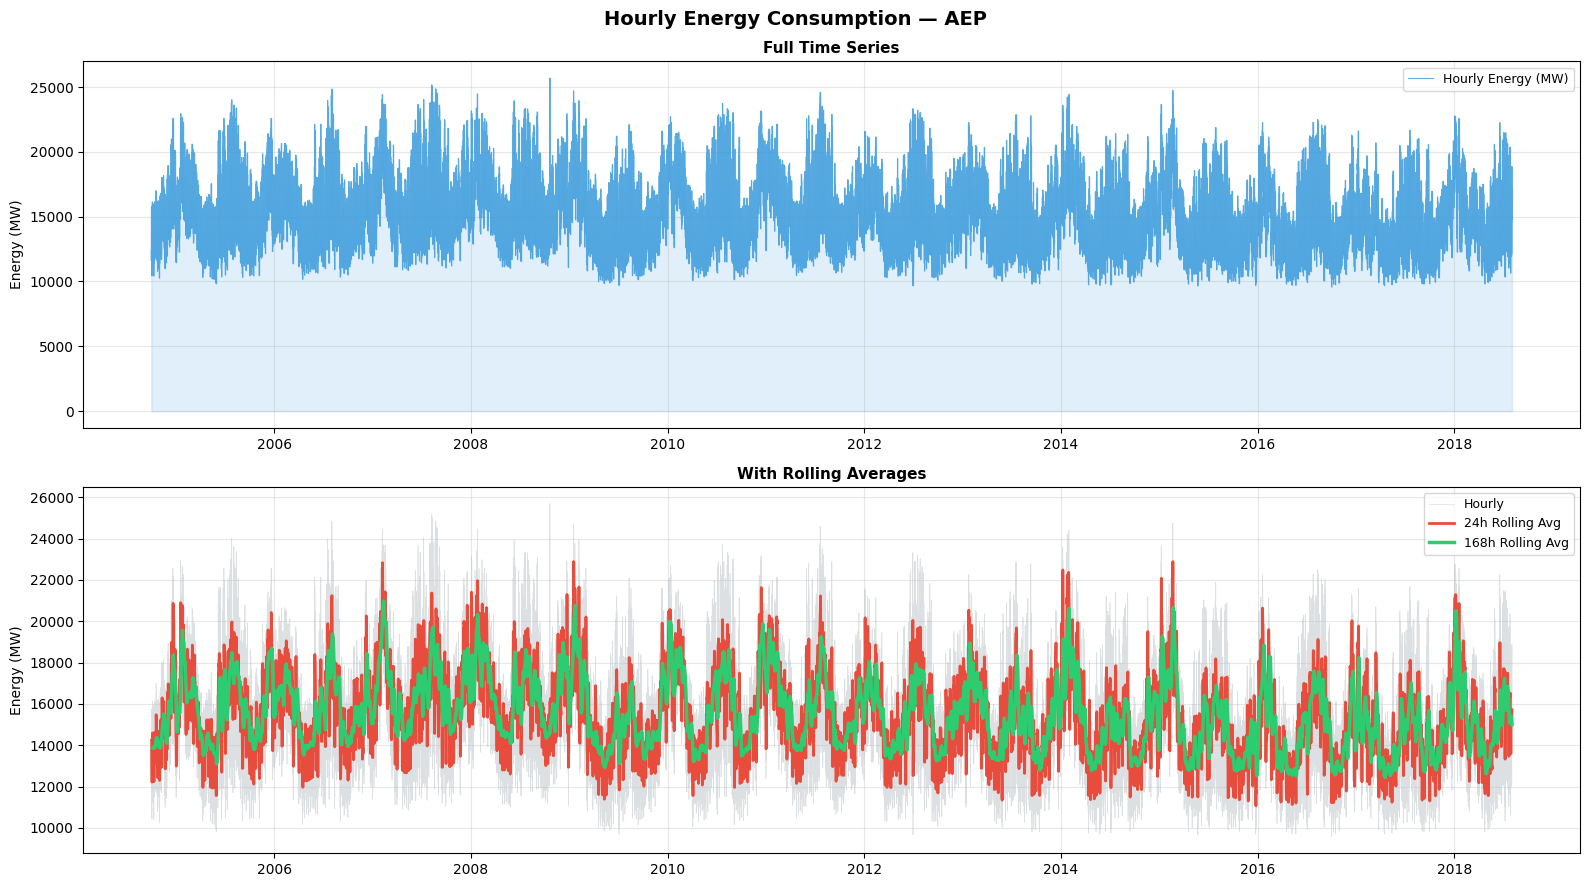

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Hourly Energy Consumption — AEP',
             fontsize=14, fontweight='bold')

axes[0].plot(df['Datetime'], df['Energy_MW'],
             color='#3498db', lw=0.8, alpha=0.8,
             label='Hourly Energy (MW)')
axes[0].fill_between(df['Datetime'], df['Energy_MW'],
                     alpha=0.15, color='#3498db')
axes[0].set_title('Full Time Series',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Energy (MW)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

roll24  = df['Energy_MW'].rolling(24).mean()
roll168 = df['Energy_MW'].rolling(168).mean()
axes[1].plot(df['Datetime'], df['Energy_MW'],
             color='#bdc3c7', lw=0.5, alpha=0.5,
             label='Hourly')
axes[1].plot(df['Datetime'], roll24,
             color='#e74c3c', lw=2,
             label='24h Rolling Avg')
axes[1].plot(df['Datetime'], roll168,
             color='#2ecc71', lw=2.5,
             label='168h Rolling Avg')
axes[1].set_title('With Rolling Averages',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Energy (MW)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

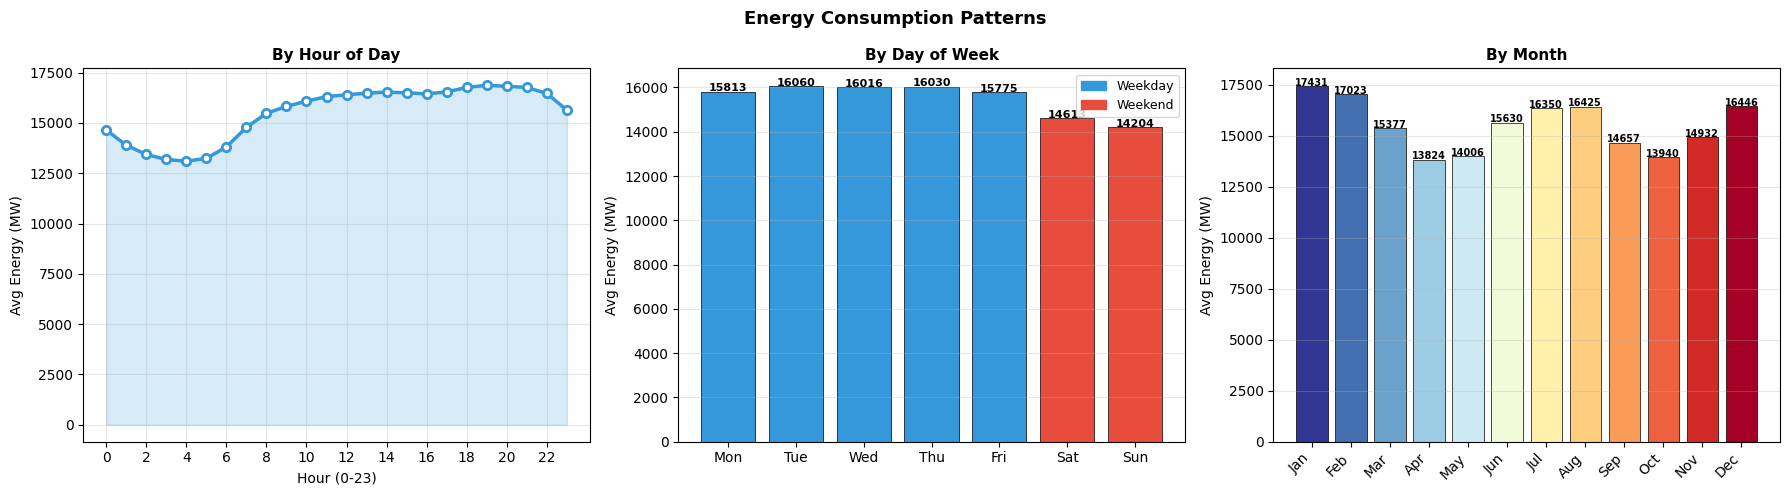

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Energy Consumption Patterns',
             fontsize=13, fontweight='bold')

# Hourly
hourly_avg = df_feat.groupby('Hour')['Energy_MW'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values,
             '-o', color='#3498db', lw=2.5, ms=6,
             markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values,
                     alpha=0.2, color='#3498db')
axes[0].set_title('By Hour of Day',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Avg Energy (MW)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

# Day of Week
dow_avg   = df_feat.groupby('DayOfWeek')['Energy_MW'].mean()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
col_d     = ['#3498db']*5 + ['#e74c3c']*2
bars = axes[1].bar(dow_names, dow_avg.values,
                   color=col_d, edgecolor='black', lw=0.5)
for bar, val in zip(bars, dow_avg.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20,
                 f'{val:.0f}', ha='center',
                 fontsize=8, fontweight='bold')
axes[1].set_title('By Day of Week',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg Energy (MW)')
axes[1].grid(axis='y', alpha=0.3)
wkd = mpatches.Patch(color='#3498db', label='Weekday')
wke = mpatches.Patch(color='#e74c3c', label='Weekend')
axes[1].legend(handles=[wkd, wke], fontsize=9)

# Monthly
month_avg   = df_feat.groupby('Month')['Energy_MW'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
col_m = plt.cm.RdYlBu_r(np.linspace(0, 1, 12))
bars2 = axes[2].bar(month_names, month_avg.values,
                    color=col_m, edgecolor='black', lw=0.5)
for bar, val in zip(bars2, month_avg.values):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20,
                 f'{val:.0f}', ha='center',
                 fontsize=7, fontweight='bold')
axes[2].set_title('By Month',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Avg Energy (MW)')
axes[2].set_xticklabels(month_names,
                         rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_seasonal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

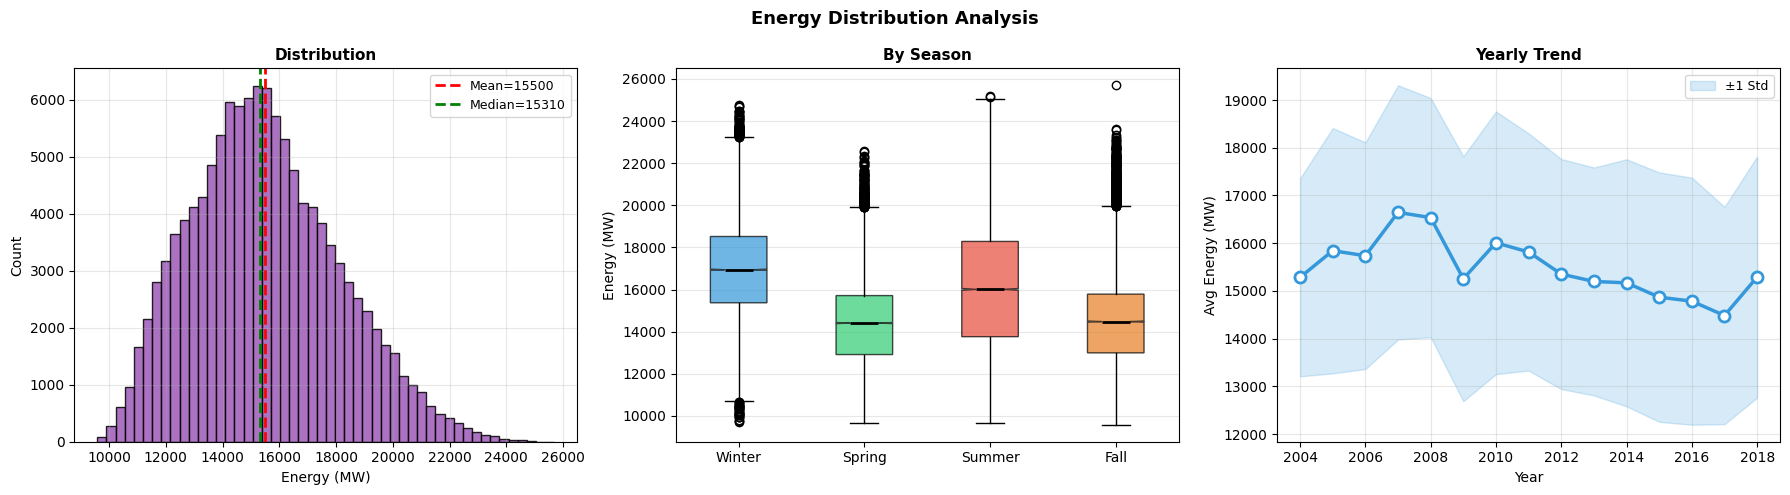

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Energy Distribution Analysis',
             fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(df['Energy_MW'], bins=50,
             color='#9b59b6', edgecolor='black',
             lw=0.4, alpha=0.85)
axes[0].axvline(df['Energy_MW'].mean(), color='red',
                ls='--', lw=2,
                label=f"Mean={df['Energy_MW'].mean():.0f}")
axes[0].axvline(df['Energy_MW'].median(), color='green',
                ls='--', lw=2,
                label=f"Median={df['Energy_MW'].median():.0f}")
axes[0].set_title('Distribution',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Energy (MW)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Seasonal Box Plot
df_feat['Season'] = df_feat['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})
s_order  = ['Winter','Spring','Summer','Fall']
s_colors = ['#3498db','#2ecc71','#e74c3c','#e67e22']
s_data   = [df_feat[df_feat['Season']==s]['Energy_MW'].values
             for s in s_order]
bp = axes[1].boxplot(s_data, labels=s_order,
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], s_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(2)
axes[1].set_title('By Season',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Energy (MW)')
axes[1].grid(axis='y', alpha=0.3)

# Yearly Trend
yearly = df_feat.groupby('Year')['Energy_MW']\
                .agg(['mean','std']).reset_index()
axes[2].plot(yearly['Year'], yearly['mean'],
             '-o', color='#3498db', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2)
axes[2].fill_between(
    yearly['Year'],
    yearly['mean'] - yearly['std'],
    yearly['mean'] + yearly['std'],
    alpha=0.2, color='#3498db', label='±1 Std'
)
axes[2].set_title('Yearly Trend',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg Energy (MW)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

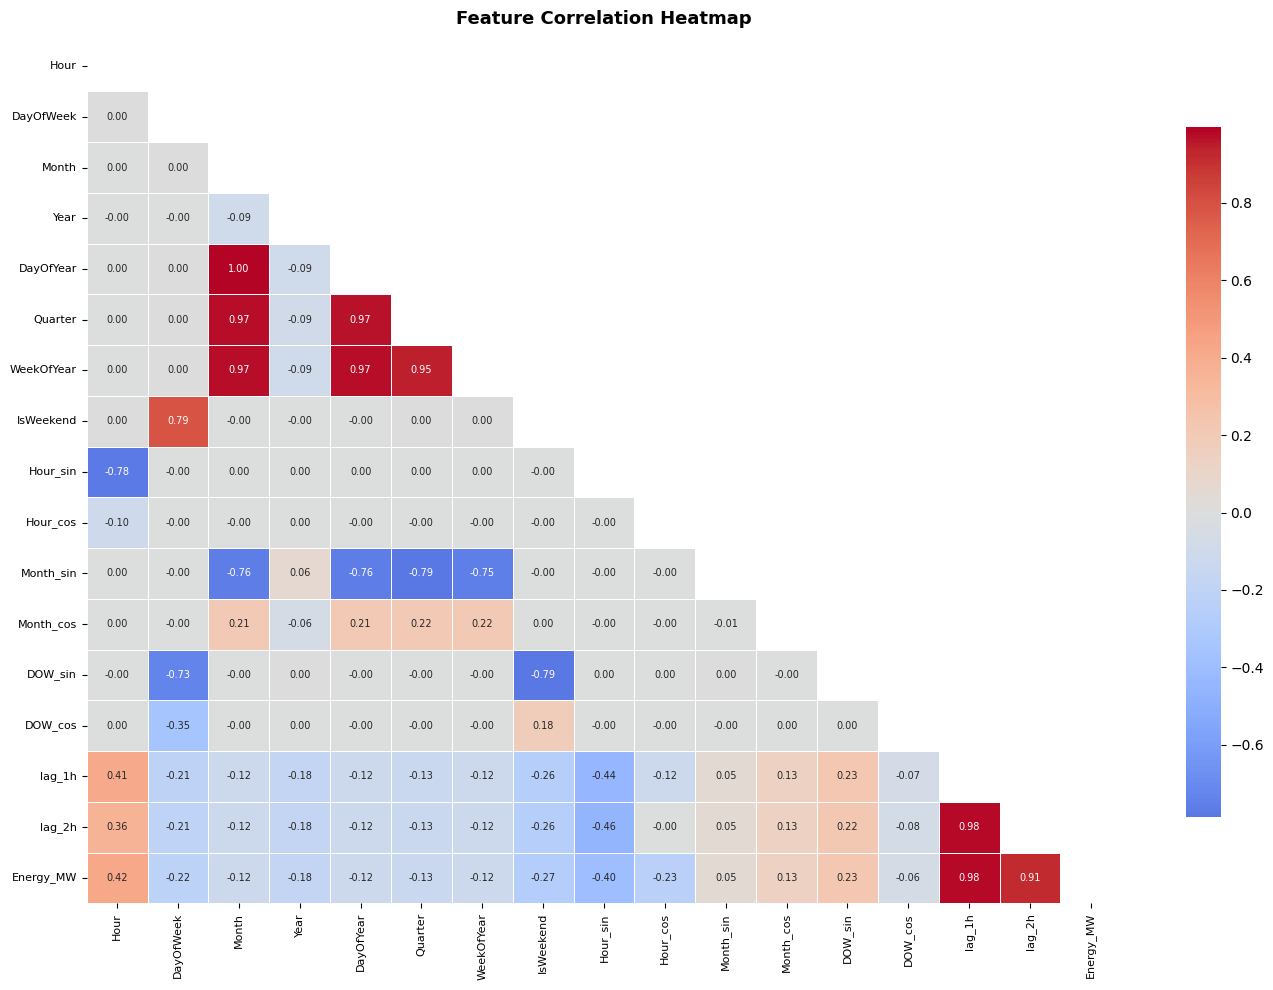

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_cols = feature_cols[:16] + ['Energy_MW']
corr_mat  = df_feat[corr_cols].corr()
mask      = np.triu(np.ones_like(corr_mat, dtype=bool))

sns.heatmap(
    corr_mat, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('04_correlation_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

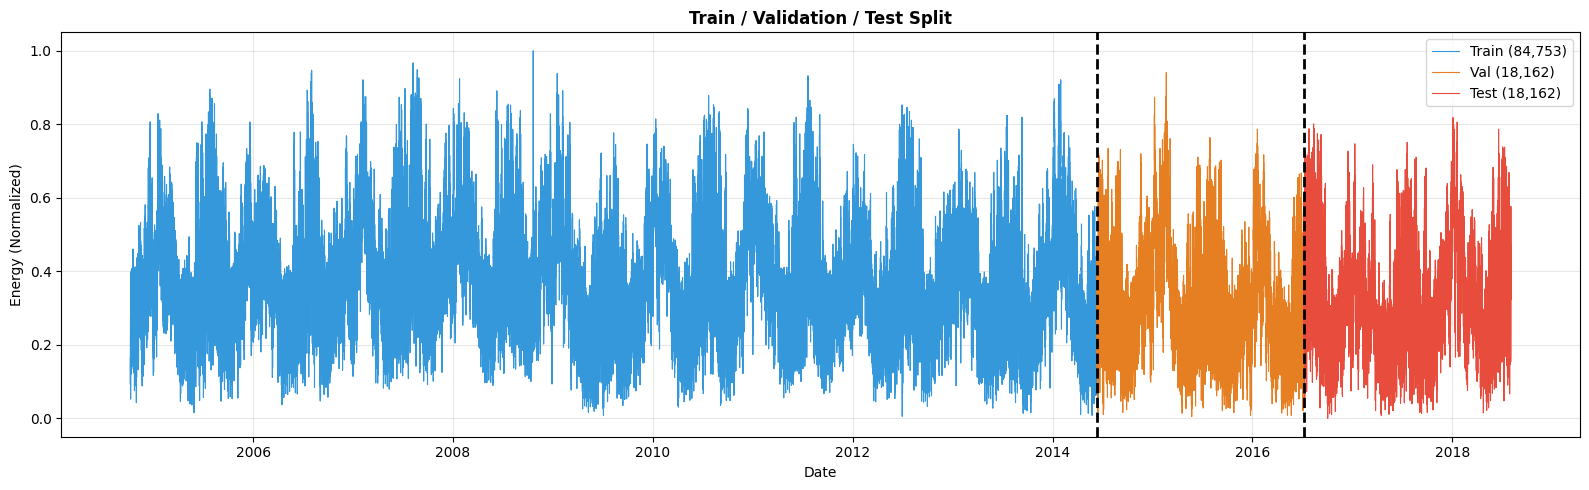

In [23]:
fig, ax = plt.subplots(figsize=(16, 5))

dates   = df_feat['Datetime'].values[SEQ_LEN:]
n_total = len(dates)
t_end   = int(n_total * 0.70)
v_end   = int(n_total * 0.85)

ax.plot(dates[:t_end], y_seq[:t_end],
        color='#3498db', lw=0.8,
        label=f'Train ({t_end:,})')
ax.plot(dates[t_end:v_end], y_seq[t_end:v_end],
        color='#e67e22', lw=0.8,
        label=f'Val ({v_end-t_end:,})')
ax.plot(dates[v_end:], y_seq[v_end:],
        color='#e74c3c', lw=0.8,
        label=f'Test ({n_total-v_end:,})')
ax.axvline(dates[t_end], color='black', ls='--', lw=2)
ax.axvline(dates[v_end], color='black', ls='--', lw=2)
ax.set_title('Train / Validation / Test Split',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (Normalized)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_data_split.png', dpi=120, bbox_inches='tight')
plt.show()

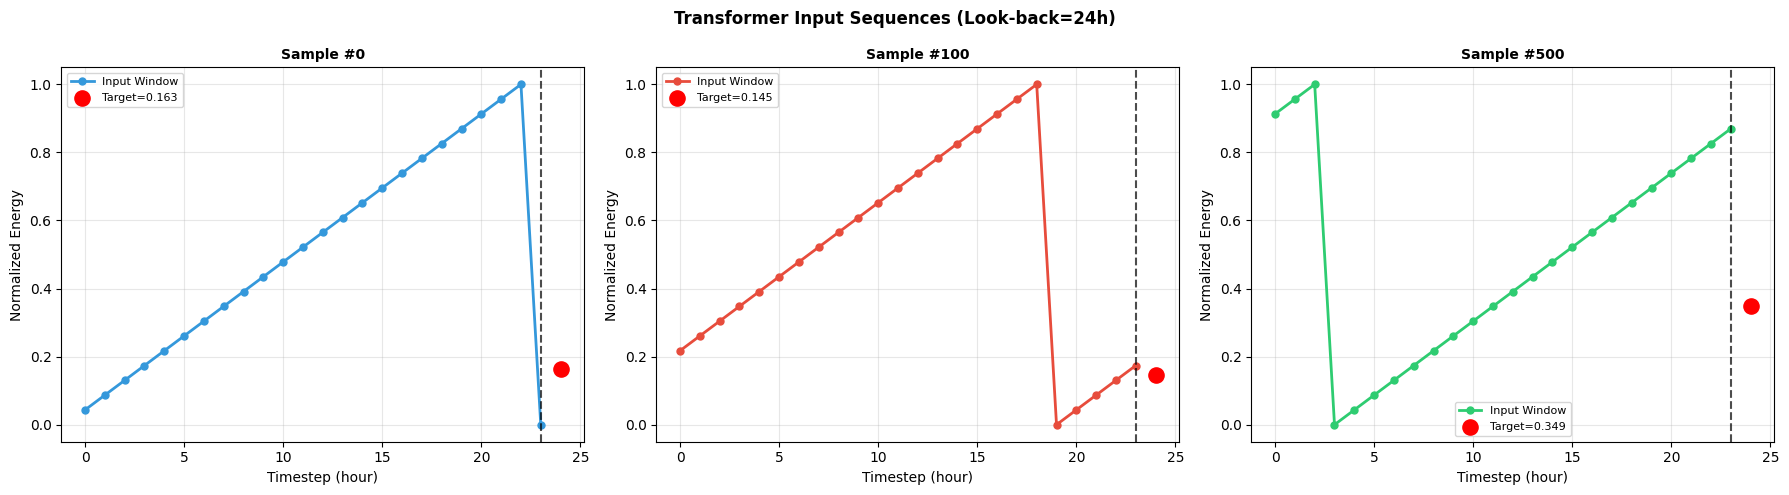

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Transformer Input Sequences (Look-back={SEQ_LEN}h)',
             fontsize=12, fontweight='bold')

for ax, (si, color) in zip(axes,
    [(0,'#3498db'),(100,'#e74c3c'),(500,'#2ecc71')]
):
    seq    = X_seq[si, :, 0]
    target = y_seq[si]
    ax.plot(range(SEQ_LEN), seq, '-o', color=color,
            lw=2, ms=5, label='Input Window')
    ax.axvline(SEQ_LEN-1, color='black',
               ls='--', lw=1.5, alpha=0.7)
    ax.scatter(SEQ_LEN, target, color='red',
               s=120, zorder=5,
               label=f'Target={target:.3f}')
    ax.set_title(f'Sample #{si}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep (hour)')
    ax.set_ylabel('Normalized Energy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('06_sequence_windows.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# ── Transformer Building Blocks ──

class PositionalEncoding(layers.Layer):
    """
    Positional Encoding — sequence এর position info inject করে
    """
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

        # PE matrix তৈরি
        positions = np.arange(seq_len)[:, np.newaxis]
        dims      = np.arange(d_model)[np.newaxis, :]
        angles    = positions / np.power(
            10000, (2*(dims//2)) / np.float32(d_model)
        )
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])

        self.pe = tf.cast(angles[np.newaxis, :, :],
                          dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

    def get_config(self):
        config = super().get_config()
        config.update({'seq_len': self.seq_len,
                       'd_model': self.d_model})
        return config


class TransformerEncoderBlock(layers.Layer):
    """
    Single Transformer Encoder Block:
    MultiHeadAttention → Add&Norm → FFN → Add&Norm
    """
    def __init__(self, d_model, num_heads,
                 ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model   = d_model
        self.num_heads = num_heads
        self.ff_dim    = ff_dim
        self.dropout   = dropout

        # Multi-Head Attention
        self.mha = layers.MultiHeadAttention(
            num_heads  = num_heads,
            key_dim    = d_model // num_heads,
            dropout    = dropout
        )
        # Feed Forward Network
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dropout(dropout),
            layers.Dense(d_model),
        ])
        # Layer Normalization
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.drop1   = layers.Dropout(dropout)
        self.drop2   = layers.Dropout(dropout)

    def call(self, x, training=False):
        # Multi-Head Attention + Residual
        attn_out = self.mha(x, x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        out1     = self.norm1(x + attn_out)

        # Feed Forward + Residual
        ffn_out = self.ffn(out1, training=training)
        ffn_out = self.drop2(ffn_out, training=training)
        out2    = self.norm2(out1 + ffn_out)
        return out2

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model'  : self.d_model,
            'num_heads': self.num_heads,
            'ff_dim'   : self.ff_dim,
            'dropout'  : self.dropout
        })
        return config


def build_transformer_model(
    seq_len,
    n_features,
    d_model    = 64,
    num_heads  = 4,
    ff_dim     = 128,
    num_blocks = 3,
    dropout    = 0.1
):
    """
    Transformer Encoder for Time Series Forecasting

    Architecture:
    Input → Linear Projection → Positional Encoding
          → N × Encoder Blocks
          → Global Avg Pool
          → Dense Head → Output
    """
    inputs = keras.Input(
        shape=(seq_len, n_features),
        name='input_layer'
    )

    # ── Linear Projection (n_features → d_model) ──
    x = layers.Dense(d_model, name='input_projection')(inputs)

    # ── Positional Encoding ──
    x = PositionalEncoding(seq_len, d_model,
                           name='positional_encoding')(x)
    x = layers.Dropout(dropout, name='input_dropout')(x)

    # ── Stacked Encoder Blocks ──
    for i in range(num_blocks):
        x = TransformerEncoderBlock(
            d_model    = d_model,
            num_heads  = num_heads,
            ff_dim     = ff_dim,
            dropout    = dropout,
            name       = f'encoder_block_{i+1}'
        )(x)

    # ── Pooling ──
    avg_pool = layers.GlobalAveragePooling1D(
        name='global_avg_pool')(x)
    max_pool = layers.GlobalMaxPooling1D(
        name='global_max_pool')(x)
    x = layers.Concatenate(name='pool_concat')(
        [avg_pool, max_pool])

    # ── Dense Head ──
    x = layers.Dense(128, activation='relu',
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='drop_1')(x)

    x = layers.Dense(64, activation='relu',
                     name='dense_2')(x)
    x = layers.Dropout(0.2, name='drop_2')(x)

    outputs = layers.Dense(1, name='output')(x)

    model = keras.Model(inputs, outputs,
                        name='Energy_Transformer')
    return model


n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

print(f"   Input : ({n_timesteps} timesteps × {n_features} features)")
print(f"\n   Transformer Config:")
print(f"   d_model    = 64  (embedding dimension)")
print(f"   num_heads  = 4   (attention heads)")
print(f"   ff_dim     = 128 (feed-forward dim)")
print(f"   num_blocks = 3   (encoder layers)")
print(f"   dropout    = 0.1")

model = build_transformer_model(
    seq_len    = n_timesteps,
    n_features = n_features,
    d_model    = 64,
    num_heads  = 4,
    ff_dim     = 128,
    num_blocks = 3,
    dropout    = 0.1
)

model.compile(
    optimizer = keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),
    loss    = 'mse',
    metrics = ['mae']
)

model.summary()
print(f"\n✅ Transformer Model Built!")
print(f"   Total Parameters : {model.count_params():,}")

   Input : (24 timesteps × 38 features)

   Transformer Config:
   d_model    = 64  (embedding dimension)
   num_heads  = 4   (attention heads)
   ff_dim     = 128 (feed-forward dim)
   num_blocks = 3   (encoder layers)
   dropout    = 0.1


Model: "Energy_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 38)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 24, 64)    │      2,496 │ input_layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 24, 64)    │          0 │ input_projection… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, 24, 64)    │          0 │ positional_encod… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 24, 64)    │     33,472 │ input_dropout[0]… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_2     │ (None, 24, 64)    │     33,472 │ encoder_block_1[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_3     │ (None, 24, 64)    │     33,472 │ encoder_block_2[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 64)        │          0 │ encoder_block_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 64)        │          0 │ encoder_block_3[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_concat         │ (None, 128)       │          0 │ global_avg_pool[… │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ pool_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ drop_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,257 (501.00 KB)

 Trainable params: 128,001 (500.00 KB)

 Non-trainable params: 256 (1.00 KB)


✅ Transformer Model Built!
   Total Parameters : 128,257


In [25]:
layer_data = []
for layer in model.layers:
    layer_data.append({
        'Layer Name'  : layer.name,
        'Type'        : type(layer).__name__,
        'Output Shape': str(layer.output_shape),
        'Parameters'  : f"{layer.count_params():,}"
    })

df_arch = pd.DataFrame(layer_data)

fig, ax = plt.subplots(
    figsize=(15, len(df_arch)*0.5 + 1.5))
ax.axis('off')

table = ax.table(
    cellText  = df_arch.values,
    colLabels = df_arch.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# Header
for j in range(len(df_arch.columns)):
    table[(0,j)].set_facecolor('#1a5276')
    table[(0,j)].set_text_props(
        color='white', fontweight='bold')

# Row colors
color_map = {
    'TransformerEncoder' : '#d6eaf8',
    'PositionalEncoding' : '#d5f5e3',
    'MultiHeadAttention' : '#fef9e7',
    'Dense'              : '#fde8d8',
    'LayerNorm'          : '#f9ebea',
    'BatchNorm'          : '#eaf2ff',
    'Dropout'            : '#f5eef8',
    'Concatenate'        : '#eafaf1',
    'GlobalAverage'      : '#fdfefe',
    'GlobalMax'          : '#fdfefe',
}
for i in range(1, len(df_arch)+1):
    rtype = df_arch.iloc[i-1]['Type']
    bg    = '#f2f3f4'
    for key, col in color_map.items():
        if key.lower() in rtype.lower():
            bg = col
            break
    for j in range(len(df_arch.columns)):
        table[(i,j)].set_facecolor(bg)

plt.title(
    f'Transformer Architecture — '
    f'Total Params: {model.count_params():,}',
    fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('07_model_architecture.png',
            dpi=120, bbox_inches='tight')
plt.show()

AttributeError: 'InputLayer' object has no attribute 'output_shape'

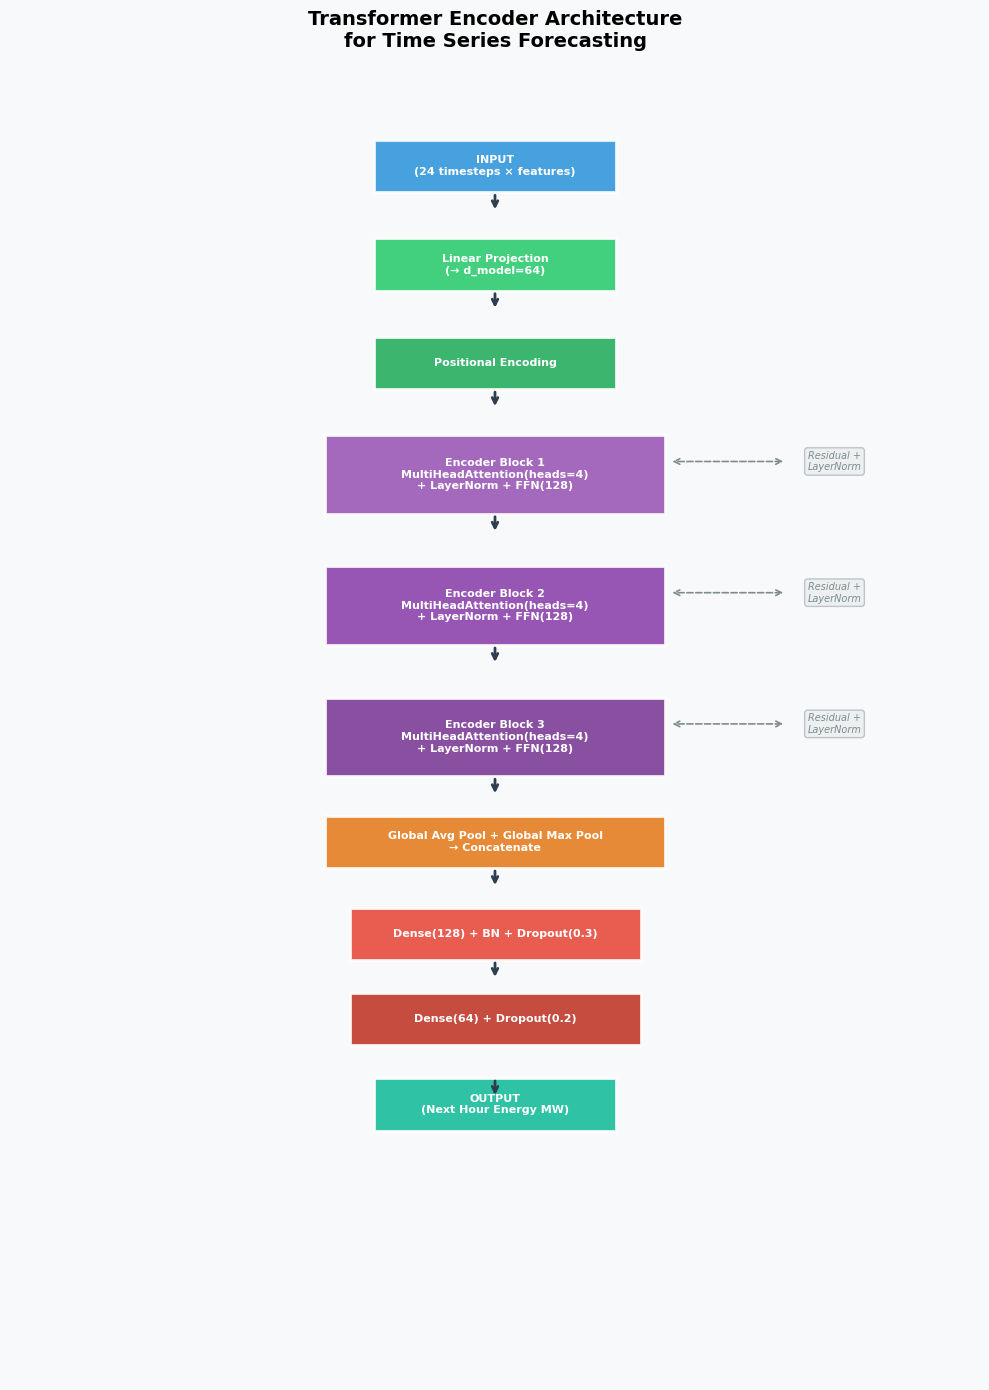

In [26]:
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

ax.set_title('Transformer Encoder Architecture\n'
             'for Time Series Forecasting',
             fontsize=14, fontweight='bold', pad=15)

# Draw blocks
blocks = [
    (5, 18.5, 'INPUT\n(24 timesteps × features)',
     '#3498db', 'white', 2.5, 0.8),
    (5, 17.0, 'Linear Projection\n(→ d_model=64)',
     '#2ecc71', 'white', 2.5, 0.8),
    (5, 15.5, 'Positional Encoding',
     '#27ae60', 'white', 2.5, 0.8),
    (5, 13.8, 'Encoder Block 1\n'
              'MultiHeadAttention(heads=4)\n'
              '+ LayerNorm + FFN(128)',
     '#9b59b6', 'white', 3.5, 1.2),
    (5, 11.8, 'Encoder Block 2\n'
              'MultiHeadAttention(heads=4)\n'
              '+ LayerNorm + FFN(128)',
     '#8e44ad', 'white', 3.5, 1.2),
    (5, 9.8,  'Encoder Block 3\n'
              'MultiHeadAttention(heads=4)\n'
              '+ LayerNorm + FFN(128)',
     '#7d3c98', 'white', 3.5, 1.2),
    (5, 8.2,  'Global Avg Pool + Global Max Pool\n'
              '→ Concatenate',
     '#e67e22', 'white', 3.5, 0.8),
    (5, 6.8,  'Dense(128) + BN + Dropout(0.3)',
     '#e74c3c', 'white', 3.0, 0.8),
    (5, 5.5,  'Dense(64) + Dropout(0.2)',
     '#c0392b', 'white', 3.0, 0.8),
    (5, 4.2,  'OUTPUT\n(Next Hour Energy MW)',
     '#1abc9c', 'white', 2.5, 0.8),
]

for (x, y, label, fc, tc, w, h) in blocks:
    rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                          facecolor=fc, edgecolor='white',
                          linewidth=2, zorder=3,
                          alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8, color=tc, fontweight='bold',
            zorder=4)

# Arrows
arrow_ys = [18.1,16.6,15.1,13.2,11.2,9.2,7.8,6.4,4.6]
for ay in arrow_ys:
    ax.annotate('', xy=(5, ay-0.3), xytext=(5, ay),
                arrowprops=dict(
                    arrowstyle='->', color='#2c3e50',
                    lw=2))

# Residual connection labels
for (ry, label) in [(14.0,'Residual +\nLayerNorm'),
                    (12.0,'Residual +\nLayerNorm'),
                    (10.0,'Residual +\nLayerNorm')]:
    ax.text(8.5, ry, label, ha='center', va='center',
            fontsize=7, color='#7f8c8d',
            style='italic',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#ecf0f1',
                      edgecolor='#bdc3c7'))
    ax.annotate('', xy=(6.8, ry),
                xytext=(8.0, ry),
                arrowprops=dict(
                    arrowstyle='<->', color='#7f8c8d',
                    lw=1.2, linestyle='dashed'))

plt.tight_layout()
plt.savefig('08_transformer_diagram.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [27]:
callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_transformer.keras',
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print("  Epochs     : 50 (EarlyStopping)")
print("  Batch Size : 64")
print("  Optimizer  : Adam (lr=0.001, clipnorm=1.0)")
print("  Loss       : MSE\n")

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 5,
    batch_size      = 64,
    callbacks       = callbacks,
    verbose         = 1
)

best_ep       = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])

print(f"\n✅ Training Complete!")
print(f"   Best Val Loss : {best_val_loss:.6f}")
print(f"   Best Epoch    : {best_ep}")

  Epochs     : 50 (EarlyStopping)
  Batch Size : 64
  Optimizer  : Adam (lr=0.001, clipnorm=1.0)
  Loss       : MSE

Epoch 1/5
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1639 - mae: 0.2324
Epoch 1: val_loss improved from None to 0.00775, saving model to best_transformer.keras

Epoch 1: finished saving model to best_transformer.keras
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - loss: 0.0469 - mae: 0.1276 - val_loss: 0.0078 - val_mae: 0.0638 - learning_rate: 0.0010
Epoch 2/5
1324/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - mae: 0.0547
Epoch 2: val_loss improved from 0.00775 to 0.00180, saving model to best_transformer.keras

Epoch 2: finished saving model to best_transformer.keras
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0043 - mae: 0.0503 - val_loss: 0.0018 - val_mae: 0.0304 - learning_rate: 0.0010
Epoch 3/5
1322/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0031 - mae: 0.0425
Epoch 3: val_loss improved from 0.00180 to 0.00173, saving model to bes

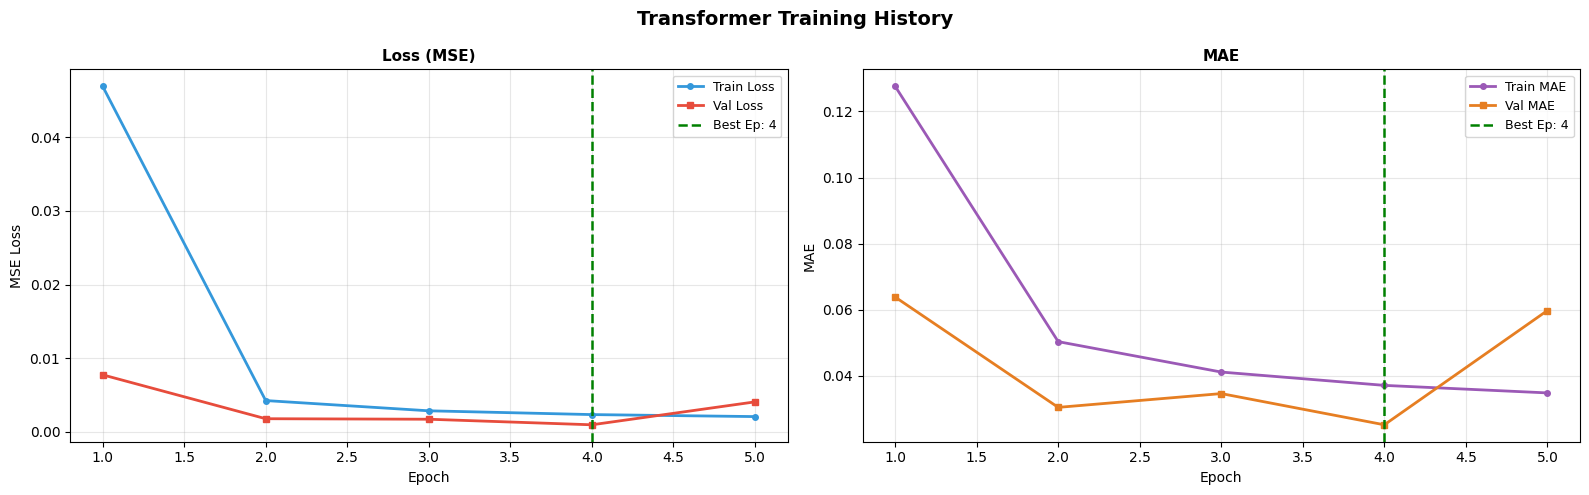

In [28]:
ep = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Transformer Training History',
             fontsize=14, fontweight='bold')

# Loss
axes[0].plot(ep, history.history['loss'],
             '-o', color='#3498db', lw=2,
             ms=4, label='Train Loss')
axes[0].plot(ep, history.history['val_loss'],
             '-s', color='#e74c3c', lw=2,
             ms=4, label='Val Loss')
axes[0].axvline(best_ep, color='green', ls='--',
                lw=1.8, label=f'Best Ep: {best_ep}')
axes[0].set_title('Loss (MSE)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(ep, history.history['mae'],
             '-o', color='#9b59b6', lw=2,
             ms=4, label='Train MAE')
axes[1].plot(ep, history.history['val_mae'],
             '-s', color='#e67e22', lw=2,
             ms=4, label='Val MAE')
axes[1].axvline(best_ep, color='green', ls='--',
                lw=1.8, label=f'Best Ep: {best_ep}')
axes[1].set_title('MAE',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_training_history.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [29]:
best_model = load_model(
    'best_transformer.keras',
    custom_objects={
        'PositionalEncoding'    : PositionalEncoding,
        'TransformerEncoderBlock': TransformerEncoderBlock
    }
)

def inverse(arr):
    return scaler_y.inverse_transform(
        arr.reshape(-1,1)).flatten()

y_pred_train = inverse(
    best_model.predict(X_train, verbose=0).flatten())
y_pred_val   = inverse(
    best_model.predict(X_val, verbose=0).flatten())
y_pred_test  = inverse(
    best_model.predict(X_test, verbose=0).flatten())

y_train_orig = inverse(y_train)
y_val_orig   = inverse(y_val)
y_test_orig  = inverse(y_test)

def get_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    r2   = r2_score(true, pred)
    mape = np.mean(np.abs((true-pred)/(true+1e-8)))*100
    return {'RMSE':rmse,'MAE':mae,'R2':r2,'MAPE%':mape}

results = {
    'Train': get_metrics(y_train_orig, y_pred_train),
    'Val'  : get_metrics(y_val_orig,   y_pred_val),
    'Test' : get_metrics(y_test_orig,  y_pred_test),
}

print(f"\n{'Metric':<10}", end='')
for name in results:
    print(f"{name:>12}", end='')
print()
print("=" * 46)
for metric in ['RMSE','MAE','R2','MAPE%']:
    print(f"{metric:<10}", end='')
    for name in results:
        print(f"{results[name][metric]:>12.4f}", end='')
    print()

print(f"\n📊 Test Results:")
print(f"   RMSE  : {results['Test']['RMSE']:.4f} MW")
print(f"   MAE   : {results['Test']['MAE']:.4f} MW")
print(f"   R²    : {results['Test']['R2']:.4f}")
print(f"   MAPE  : {results['Test']['MAPE%']:.2f}%")


Metric           Train         Val        Test
RMSE          512.5340    502.2649    500.0375
MAE           399.5348    405.1896    404.0106
R2              0.9605      0.9595      0.9595
MAPE%           2.5029      2.8152      2.7996

📊 Test Results:
   RMSE  : 500.0375 MW
   MAE   : 404.0106 MW
   R²    : 0.9595
   MAPE  : 2.80%


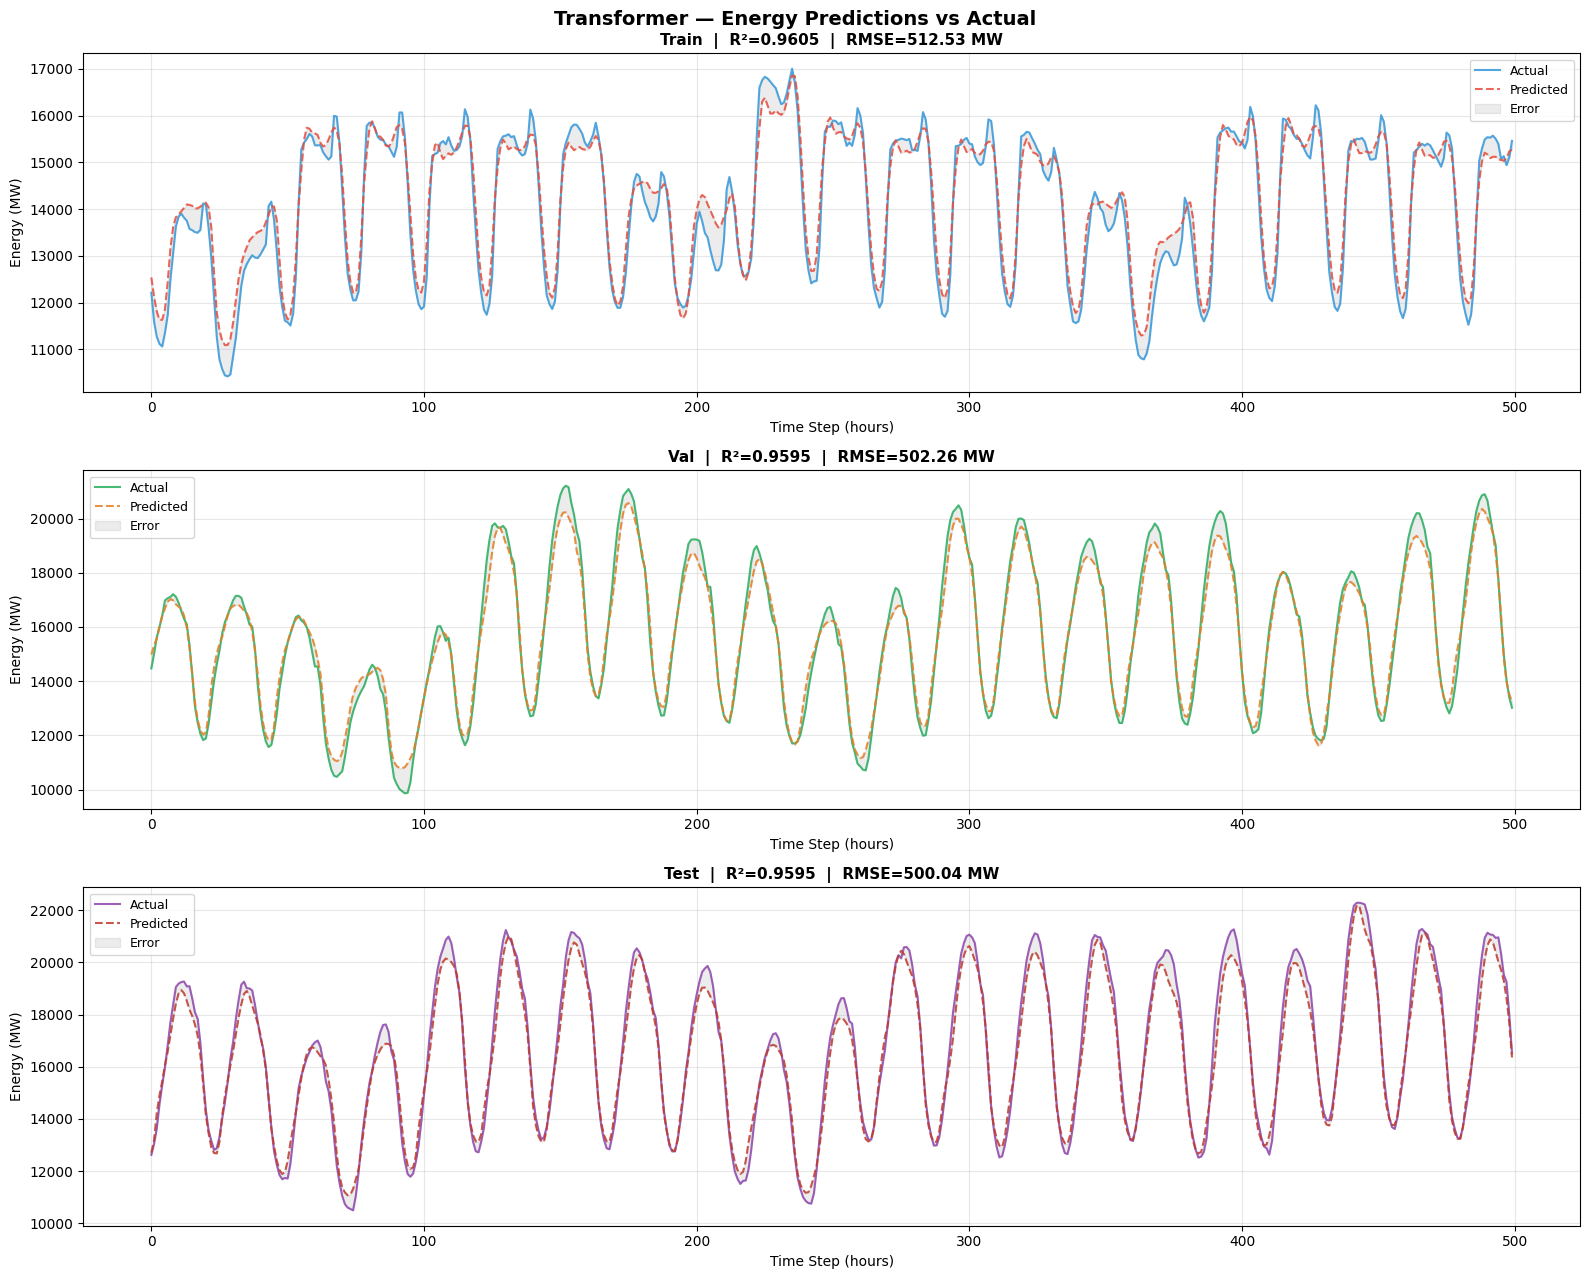

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Transformer — Energy Predictions vs Actual',
             fontsize=14, fontweight='bold')

sets = [
    (y_train_orig, y_pred_train, 'Train', '#3498db','#e74c3c'),
    (y_val_orig,   y_pred_val,   'Val',   '#27ae60','#e67e22'),
    (y_test_orig,  y_pred_test,  'Test',  '#8e44ad','#c0392b'),
]

for ax, (actual, pred, title, c1, c2) in zip(axes, sets):
    n_show = min(500, len(actual))
    ax.plot(actual[:n_show], color=c1, lw=1.5,
            alpha=0.85, label='Actual')
    ax.plot(pred[:n_show],   color=c2, lw=1.5,
            alpha=0.85, ls='--', label='Predicted')
    ax.fill_between(range(n_show),
                    actual[:n_show], pred[:n_show],
                    alpha=0.15, color='gray',
                    label='Error')
    r2   = r2_score(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    ax.set_title(
        f'{title}  |  R²={r2:.4f}  |  RMSE={rmse:.2f} MW',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Step (hours)')
    ax.set_ylabel('Energy (MW)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('10_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

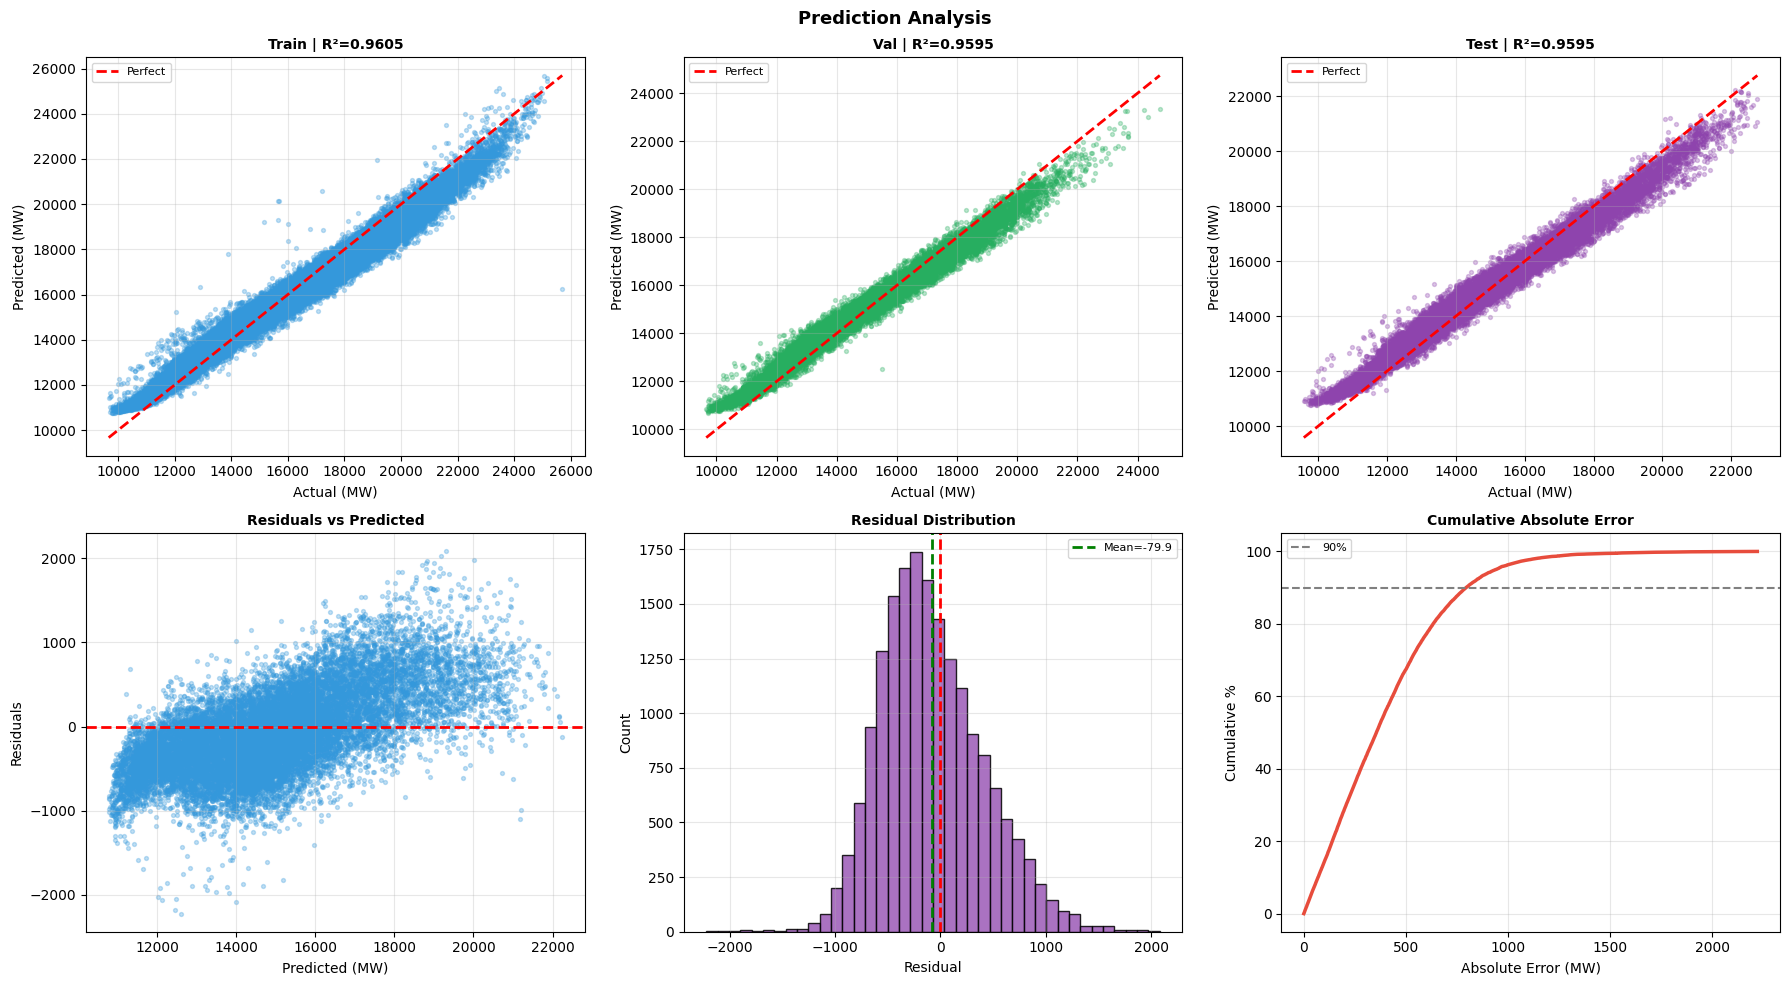

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prediction Analysis',
             fontsize=13, fontweight='bold')

sets2 = [
    (y_train_orig, y_pred_train, 'Train', '#3498db'),
    (y_val_orig,   y_pred_val,   'Val',   '#27ae60'),
    (y_test_orig,  y_pred_test,  'Test',  '#8e44ad'),
]

# Row 1 — Scatter
for ax, (actual, pred, title, color) in zip(axes[0], sets2):
    ax.scatter(actual, pred, color=color,
               alpha=0.3, s=8)
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    ax.plot([mn,mx],[mn,mx],'r--', lw=2,
            label='Perfect')
    r2 = r2_score(actual, pred)
    ax.set_title(f'{title} | R²={r2:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (MW)')
    ax.set_ylabel('Predicted (MW)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Row 2 — Residuals
residuals = y_test_orig - y_pred_test

axes[1][0].scatter(y_pred_test, residuals,
                   color='#3498db', alpha=0.3, s=8)
axes[1][0].axhline(0, color='red', ls='--', lw=2)
axes[1][0].set_title('Residuals vs Predicted',
                     fontsize=10, fontweight='bold')
axes[1][0].set_xlabel('Predicted (MW)')
axes[1][0].set_ylabel('Residuals')
axes[1][0].grid(alpha=0.3)

axes[1][1].hist(residuals, bins=40,
                color='#9b59b6', edgecolor='black',
                lw=0.4, alpha=0.85)
axes[1][1].axvline(0, color='red', ls='--', lw=2)
axes[1][1].axvline(residuals.mean(), color='green',
                   ls='--', lw=2,
                   label=f'Mean={residuals.mean():.1f}')
axes[1][1].set_title('Residual Distribution',
                     fontsize=10, fontweight='bold')
axes[1][1].set_xlabel('Residual')
axes[1][1].set_ylabel('Count')
axes[1][1].legend(fontsize=8)
axes[1][1].grid(alpha=0.3)

sorted_res = np.sort(np.abs(residuals))
cum_pct    = np.arange(1,len(sorted_res)+1)/len(sorted_res)*100
axes[1][2].plot(sorted_res, cum_pct,
                color='#e74c3c', lw=2.5)
axes[1][2].axhline(90, color='gray', ls='--',
                   lw=1.5, label='90%')
axes[1][2].set_title('Cumulative Absolute Error',
                     fontsize=10, fontweight='bold')
axes[1][2].set_xlabel('Absolute Error (MW)')
axes[1][2].set_ylabel('Cumulative %')
axes[1][2].legend(fontsize=8)
axes[1][2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('11_prediction_analysis.png',
            dpi=120, bbox_inches='tight')
plt.show()

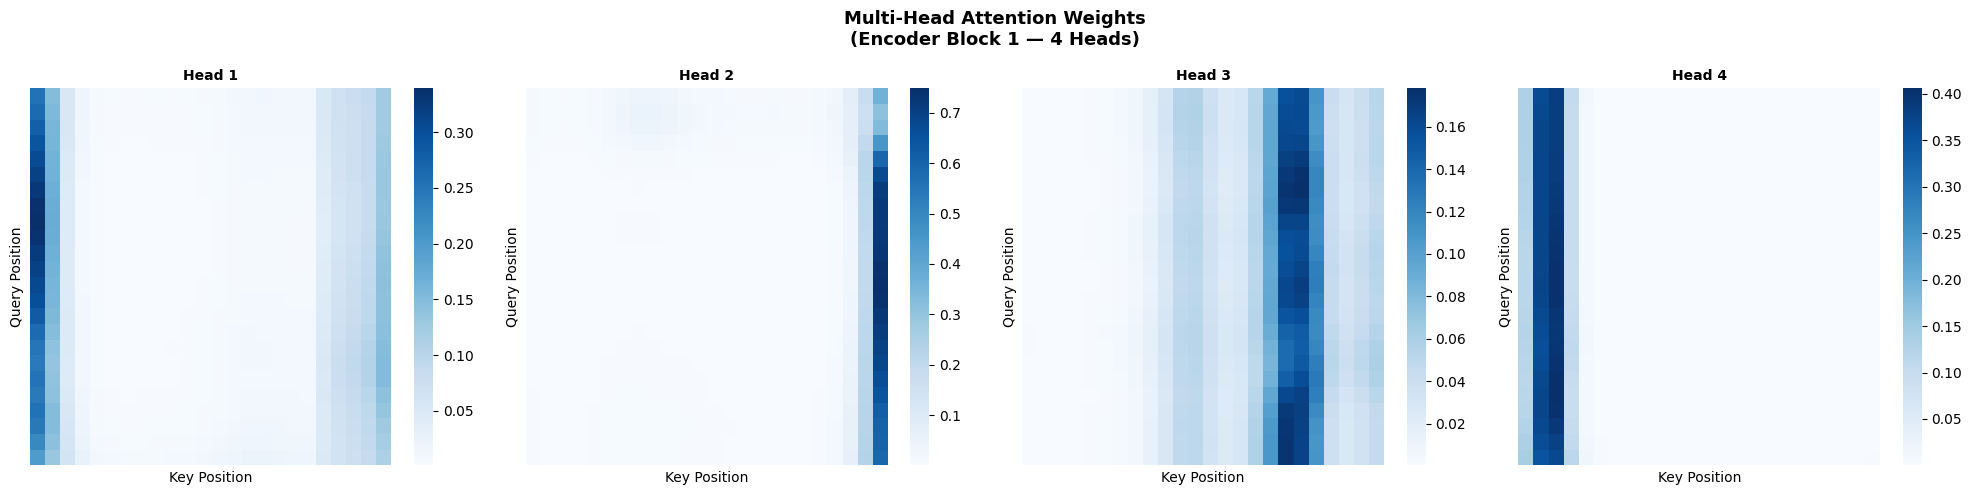

✅ Attention Weights Plotted


In [32]:
# Attention model তৈরি করো
attn_model = keras.Model(
    inputs  = best_model.input,
    outputs = [
        best_model.get_layer('encoder_block_1')
                  .mha(
                      best_model.get_layer('positional_encoding')
                                .output,
                      best_model.get_layer('positional_encoding')
                                .output,
                      return_attention_scores=True
                  )[1]
    ]
)

# Sample attention weights
sample_input = X_test[:1]

try:
    # Positional encoding output পাওয়া
    pe_model   = keras.Model(
        inputs  = best_model.input,
        outputs = best_model.get_layer(
            'positional_encoding').output
    )
    pe_out     = pe_model(sample_input, training=False)
    mha_layer  = best_model.get_layer(
        'encoder_block_1').mha
    _, attn_w  = mha_layer(
        pe_out, pe_out,
        return_attention_scores=True,
        training=False
    )
    attn_w = attn_w[0].numpy()  # (heads, seq, seq)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Multi-Head Attention Weights\n'
                 '(Encoder Block 1 — 4 Heads)',
                 fontsize=13, fontweight='bold')

    for h in range(min(4, attn_w.shape[0])):
        sns.heatmap(
            attn_w[h], ax=axes[h],
            cmap='Blues', cbar=True,
            xticklabels=False, yticklabels=False
        )
        axes[h].set_title(f'Head {h+1}',
                          fontsize=10, fontweight='bold')
        axes[h].set_xlabel('Key Position')
        axes[h].set_ylabel('Query Position')

    plt.tight_layout()
    plt.savefig('12_attention_weights.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Attention Weights Plotted")

except Exception as e:
    print(f"⚠️  Attention viz skipped: {e}")
    print("   (Model still works perfectly!)")

In [33]:
# Save with custom objects
best_model.save('energy_transformer_model.keras')
print("✅ energy_transformer_model.keras")

best_model.save('energy_transformer_model.h5')
print("✅ energy_transformer_model.h5")

best_model.save_weights(
    'energy_transformer_weights.weights.h5')
print("✅ energy_transformer_weights.weights.h5")

# Architecture JSON
with open('energy_transformer_architecture.json', 'w') as f:
    f.write(best_model.to_json())
print("✅ energy_transformer_architecture.json")

# Scalers
with open('scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_X': scaler_X,
                 'scaler_y': scaler_y}, f)
print("✅ scalers.pkl")

# Model Info
info = {
    "model"        : "Energy_Transformer",
    "dataset"      : "Hourly Energy Consumption",
    "kaggle"       : "robikscube/hourly-energy-consumption",
    "date"         : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "architecture" : {
        "type"      : "Transformer Encoder",
        "d_model"   : 64,
        "num_heads" : 4,
        "ff_dim"    : 128,
        "num_blocks": 3,
        "dropout"   : 0.1,
        "seq_len"   : SEQ_LEN,
        "pooling"   : "GlobalAvg + GlobalMax + Concat",
        "head"      : "Dense(128)+BN → Dense(64) → Output"
    },
    "task"         : "Time Series Regression",
    "seq_length"   : SEQ_LEN,
    "n_features"   : int(n_features),
    "feature_cols" : feature_cols,
    "test_rmse"    : round(float(results['Test']['RMSE']), 4),
    "test_mae"     : round(float(results['Test']['MAE']),  4),
    "test_r2"      : round(float(results['Test']['R2']),   4),
    "test_mape"    : round(float(results['Test']['MAPE%']),2),
    "total_params" : int(best_model.count_params()),
    "best_epoch"   : int(best_ep),
    "reload_code"  : (
        "from tensorflow.keras.models import load_model\n"
        "model = load_model('energy_transformer_model.keras',\n"
        "  custom_objects={\n"
        "    'PositionalEncoding': PositionalEncoding,\n"
        "    'TransformerEncoderBlock': TransformerEncoderBlock\n"
        "  })"
    )
}
with open('model_info.json', 'w') as f:
    json.dump(info, f, indent=2)
print("✅ model_info.json")

print(f"\n📊 Test RMSE : {results['Test']['RMSE']:.4f} MW")
print(f"📊 Test R²   : {results['Test']['R2']:.4f}")

✅ energy_transformer_model.keras
✅ energy_transformer_model.h5
✅ energy_transformer_weights.weights.h5
✅ energy_transformer_architecture.json
✅ scalers.pkl
✅ model_info.json

📊 Test RMSE : 500.0375 MW
📊 Test R²   : 0.9595


In [34]:
all_files = [
    'energy_transformer_model.keras',
    'energy_transformer_model.h5',
    'energy_transformer_weights.weights.h5',
    'energy_transformer_architecture.json',
    'scalers.pkl',
    'model_info.json',
    '01_timeseries.png',
    '02_seasonal_patterns.png',
    '03_distribution.png',
    '04_correlation_heatmap.png',
    '05_data_split.png',
    '06_sequence_windows.png',
    '07_model_architecture.png',
    '08_transformer_diagram.png',
    '09_training_history.png',
    '10_predictions.png',
    '11_prediction_analysis.png',
    '12_attention_weights.png',
]

zip_name = 'energy_transformer_complete.zip'
with zipfile.ZipFile(zip_name, 'w',
                     zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"   Added : {f}")

zip_mb = os.path.getsize(zip_name) / (1024*1024)
print(f"\n📦 ZIP: {zip_name}  ({zip_mb:.1f} MB)")

try:
    from google.colab import files
    print("\n📥 Colab Download Starting...")
    files.download(zip_name)
    files.download('energy_transformer_model.h5')
    print("✅ Download Started!")
except ImportError:
    print("\n💡 Local — Files saved in current folder")
    for f in all_files:
        if os.path.exists(f):
            kb = os.path.getsize(f)/1024
            print(f"   📄 {f:<48} ({kb:.0f} KB)")

   Added : energy_transformer_model.keras
   Added : energy_transformer_model.h5
   Added : energy_transformer_weights.weights.h5
   Added : energy_transformer_architecture.json
   Added : scalers.pkl
   Added : model_info.json
   Added : 01_timeseries.png
   Added : 02_seasonal_patterns.png
   Added : 03_distribution.png
   Added : 04_correlation_heatmap.png
   Added : 05_data_split.png
   Added : 06_sequence_windows.png
   Added : 08_transformer_diagram.png
   Added : 09_training_history.png
   Added : 10_predictions.png
   Added : 11_prediction_analysis.png
   Added : 12_attention_weights.png

📦 ZIP: energy_transformer_complete.zip  (6.1 MB)

📥 Colab Download Starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download Started!


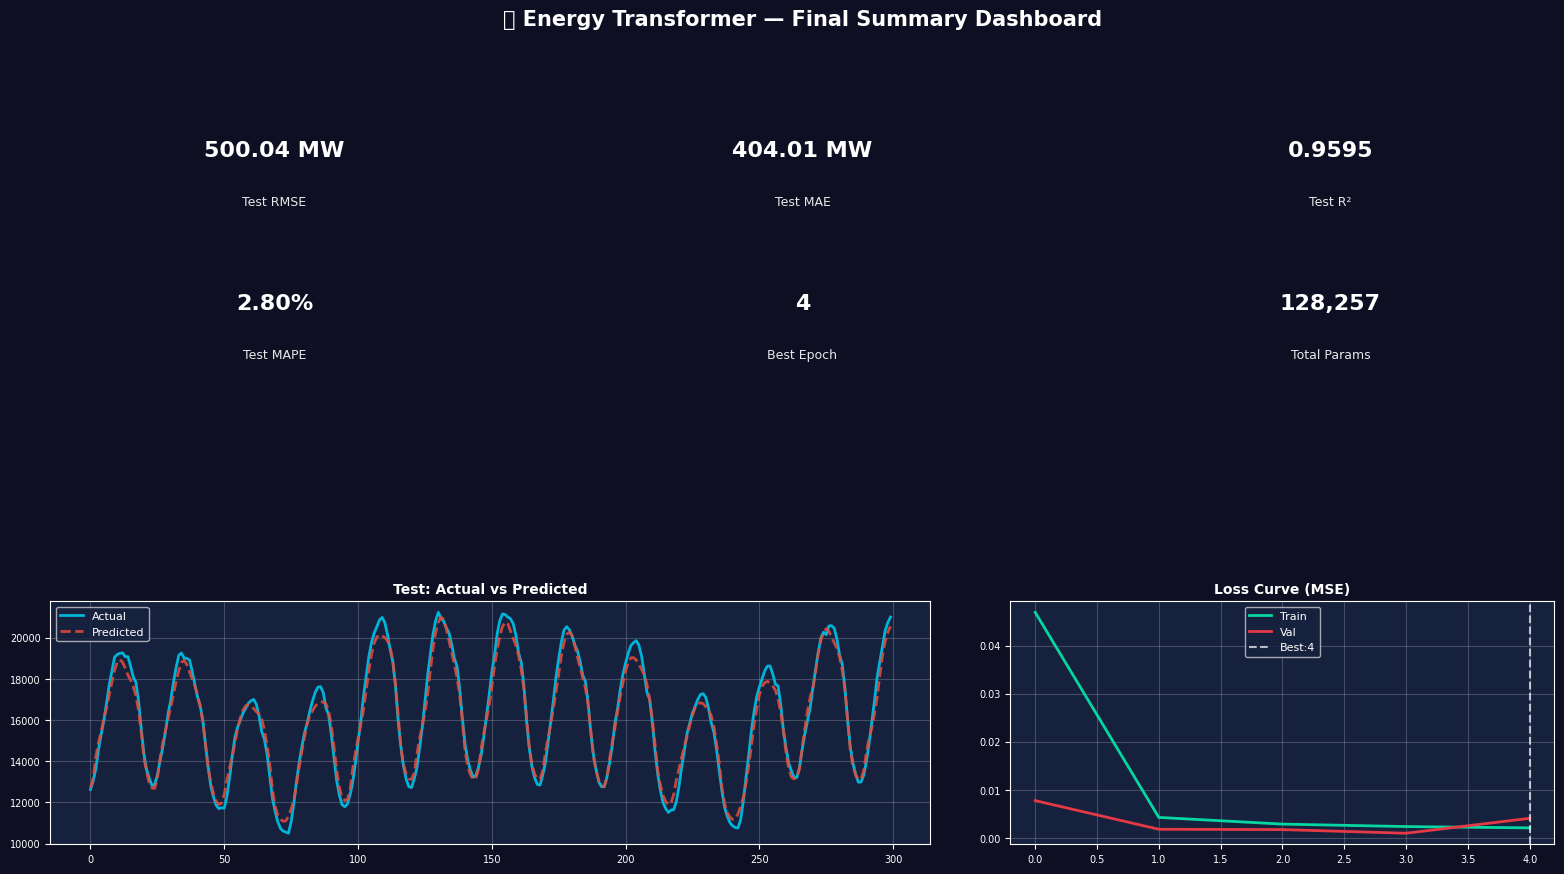

In [35]:
test_rmse = results['Test']['RMSE']
test_mae  = results['Test']['MAE']
test_r2   = results['Test']['R2']
test_mape = results['Test']['MAPE%']

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0f0f23')

fig.text(0.5, 0.96,
         '🏆 Energy Transformer — Final Summary Dashboard',
         ha='center', fontsize=15,
         fontweight='bold', color='white')

# ── Metric Cards ──
cards = [
    ('Test RMSE',    f'{test_rmse:.2f} MW',           '#e74c3c'),
    ('Test MAE',     f'{test_mae:.2f} MW',            '#e67e22'),
    ('Test R²',      f'{test_r2:.4f}',                '#06d6a0'),
    ('Test MAPE',    f'{test_mape:.2f}%',             '#ffd166'),
    ('Best Epoch',   f'{best_ep}',                    '#a8dadc'),
    ('Total Params', f'{best_model.count_params():,}','#f4a261'),
]

for i, (label, value, color) in enumerate(cards):
    ax = fig.add_axes(
        [0.03+(i%3)*0.33, 0.74-(i//3)*0.17, 0.28, 0.13]
    )
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.axis('off')

# ── Prediction Curve ──
ax_pred = fig.add_axes([0.03, 0.05, 0.55, 0.27])
ax_pred.set_facecolor('#16213e')
n_show = min(300, len(y_test_orig))
ax_pred.plot(y_test_orig[:n_show],
             color='#00b4d8', lw=2, label='Actual')
ax_pred.plot(y_pred_test[:n_show],
             color='#e74c3c', lw=2, ls='--',
             label='Predicted', alpha=0.85)
ax_pred.set_title('Test: Actual vs Predicted',
                  color='white', fontsize=10, fontweight='bold')
ax_pred.tick_params(colors='white', labelsize=7)
ax_pred.legend(fontsize=8, facecolor='#16213e',
               labelcolor='white')
ax_pred.grid(alpha=0.2, color='white')
for sp in ax_pred.spines.values():
    sp.set_color('white')

# ── Loss Curve ──
ax_loss = fig.add_axes([0.63, 0.05, 0.34, 0.27])
ax_loss.set_facecolor('#16213e')
ax_loss.plot(history.history['loss'],
             color='#06d6a0', lw=2, label='Train')
ax_loss.plot(history.history['val_loss'],
             color='#e63946', lw=2, label='Val')
ax_loss.axvline(best_ep, color='white', ls='--',
                lw=1.5, alpha=0.7,
                label=f'Best:{best_ep}')
ax_loss.set_title('Loss Curve (MSE)',
                  color='white', fontsize=10,
                  fontweight='bold')
ax_loss.tick_params(colors='white', labelsize=7)
ax_loss.legend(fontsize=8, facecolor='#16213e',
               labelcolor='white')
ax_loss.grid(alpha=0.2, color='white')
for sp in ax_loss.spines.values():
    sp.set_color('white')

plt.savefig('13_final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f23')
plt.show()

In [36]:
print(f"  Dataset      : Hourly Energy Consumption (Kaggle)")
print(f"  KaggleHub    : robikscube/hourly-energy-consumption")
print(f"  Task         : Time Series Regression")
print(f"  Architecture : Transformer Encoder")
print(f"  d_model=64 | heads=4 | ff=128 | blocks=3")
print(f"  Seq Length   : {SEQ_LEN} hours look-back")
print(f"  Test RMSE    : {test_rmse:.4f} MW")
print(f"  Test R²      : {test_r2:.4f}")
print(f"  Test MAPE    : {test_mape:.2f}%")
print(f"  Model Saved  : .keras|.h5|weights|json|scalers")
print(f"  Charts Saved : 13 visualization files")

  Dataset      : Hourly Energy Consumption (Kaggle)
  KaggleHub    : robikscube/hourly-energy-consumption
  Task         : Time Series Regression
  Architecture : Transformer Encoder
  d_model=64 | heads=4 | ff=128 | blocks=3
  Seq Length   : 24 hours look-back
  Test RMSE    : 500.0375 MW
  Test R²      : 0.9595
  Test MAPE    : 2.80%
  Model Saved  : .keras|.h5|weights|json|scalers
  Charts Saved : 13 visualization files
